# **Denoising Autoencoder on MNIST**
**WEEK 6 ASSIGNMENT - SIYA BHASIN**


- Noise is added to inputs
- Training pairs are `(noisy_image -> clean_image)`

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load and Preprocess MNIST

In [2]:
transform = transforms.ToTensor()  # scales pixels to [0, 1]

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.98MB/s]


## 3. Noise Function

Adds Gaussian noise to images and clips values back to `[0, 1]`.

In [3]:
NOISE_FACTOR = 0.5

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

## 4. Define the Denoising Autoencoder

Encoder/decoder of linear layers, following the reference repo's pattern (784 -> 256 -> 64 -> 256 -> 784).

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 784 -> 256 -> 64 (compressed representation)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
        )
        # Decoder: 64 -> 256 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # output in [0, 1], matching normalized input
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten (N, 1, 28, 28) -> (N, 784)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(-1, 1, 28, 28)
        return decoded

model = DenoisingAutoencoder().to(device)
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## 5. Training Setup

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 20

train_losses, val_losses = [], []

## 6. Training Loop

For each batch:
1. Add noise to the input images
2. Pass **noisy** images through the model
3. Compare reconstruction to the **clean** original images (loss target)

In [6]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images)

        optimizer.zero_grad()
        outputs = model(noisy_images)          # noisy -> reconstruction
        loss = criterion(outputs, images)      # compare to CLEAN target
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_data)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy_images = add_noise(images)
            outputs = model(noisy_images)
            loss = criterion(outputs, images)
            val_running_loss += loss.item() * images.size(0)

    val_loss = val_running_loss / len(test_data)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch}/{EPOCHS}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

Epoch [1/20]  Train Loss: 0.0512  Val Loss: 0.0319
Epoch [2/20]  Train Loss: 0.0280  Val Loss: 0.0251
Epoch [3/20]  Train Loss: 0.0236  Val Loss: 0.0215
Epoch [4/20]  Train Loss: 0.0211  Val Loss: 0.0199
Epoch [5/20]  Train Loss: 0.0198  Val Loss: 0.0187
Epoch [6/20]  Train Loss: 0.0187  Val Loss: 0.0180
Epoch [7/20]  Train Loss: 0.0179  Val Loss: 0.0171
Epoch [8/20]  Train Loss: 0.0174  Val Loss: 0.0167
Epoch [9/20]  Train Loss: 0.0169  Val Loss: 0.0163
Epoch [10/20]  Train Loss: 0.0165  Val Loss: 0.0161
Epoch [11/20]  Train Loss: 0.0161  Val Loss: 0.0157
Epoch [12/20]  Train Loss: 0.0159  Val Loss: 0.0155
Epoch [13/20]  Train Loss: 0.0157  Val Loss: 0.0154
Epoch [14/20]  Train Loss: 0.0155  Val Loss: 0.0151
Epoch [15/20]  Train Loss: 0.0153  Val Loss: 0.0150
Epoch [16/20]  Train Loss: 0.0151  Val Loss: 0.0148
Epoch [17/20]  Train Loss: 0.0150  Val Loss: 0.0147
Epoch [18/20]  Train Loss: 0.0149  Val Loss: 0.0147
Epoch [19/20]  Train Loss: 0.0148  Val Loss: 0.0145
Epoch [20/20]  Train 

## 7. Visualize Results: Noisy / Denoised / Original

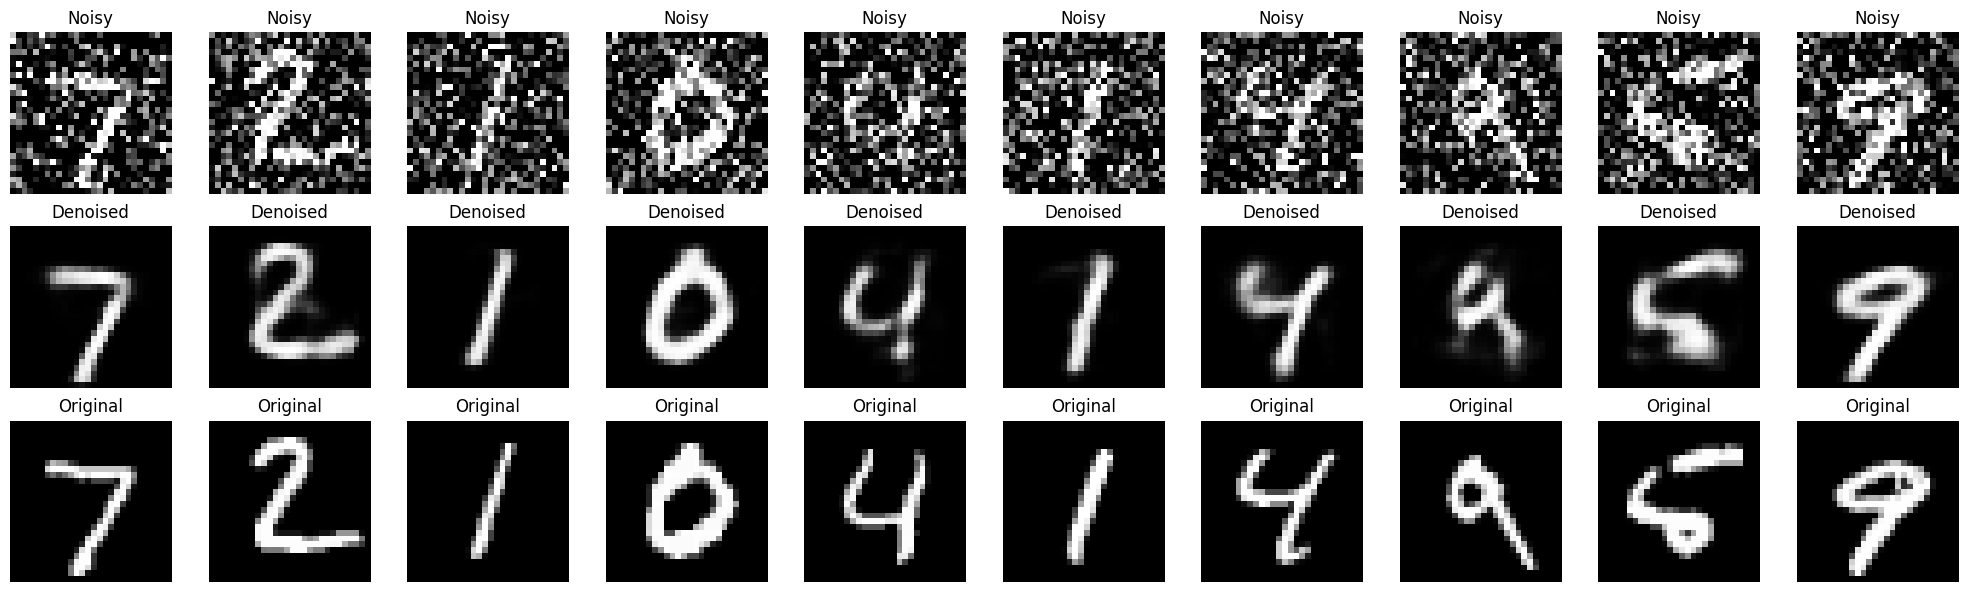

In [7]:
model.eval()
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
noisy_test_images = add_noise(test_images)

with torch.no_grad():
    denoised_images = model(noisy_test_images)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(noisy_test_images[i].cpu().squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].cpu().squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # Original
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(test_images[i].cpu().squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.savefig("denoising_results.png", dpi=150)
plt.show()

## 8. Plot Training / Validation Loss

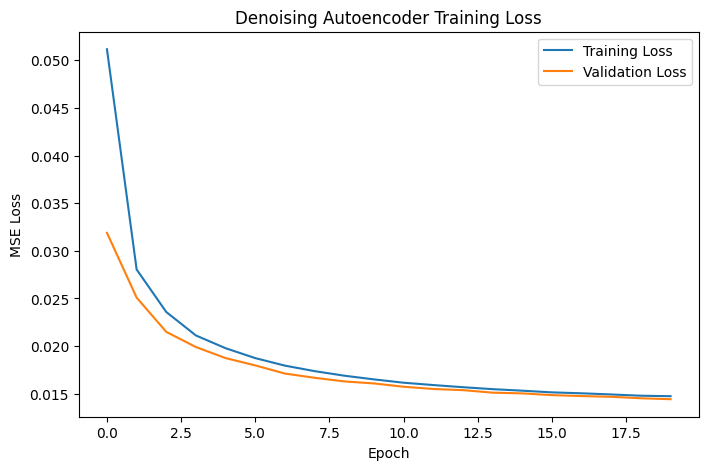

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Denoising Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.savefig("training_loss.png", dpi=150)
plt.show()

## 9. Save Model

In [9]:
torch.save(model.state_dict(), "denoising_autoencoder.pth")
print("Model saved as denoising_autoencoder.pth")

Model saved as denoising_autoencoder.pth


## 10. Observations / Analysis

**Training behavior:** Training loss dropped sharply from ~0.053 to ~0.029 in the first epoch, then decreased smoothly to ~0.0154 by epoch 20. Validation loss followed the same trend, ending at ~0.0151, consistently tracking slightly below training loss — indicating no overfitting and good generalization.


**Denoising performance:** The model successfully removes the heavy Gaussian noise (factor 0.5) while preserving overall digit shape and stroke structure. Digits like 0, 4, 7, and 9 are reconstructed clearly and are easily readable.


**Challenges/limitations:** Reconstructions are visibly blurred and lose sharp edges — visible in digits like 2, 4, and 6, where stroke thickness and curve sharpness are softened. This is a known limitation of fully-connected (linear) autoencoders: flattening the image to a 784-d vector discards spatial/local pixel relationships that convolutional layers would preserve. The "5" output is also slightly ambiguous (resembles a 6/9 shape) — likely due to the bottleneck (64-d) being too small to retain finer distinguishing detail for visually similar digits under heavy noise.


**Key takeaway:** The 784→256→64→256→784 linear autoencoder is sufficient for noise removal and basic structure recovery, but a convolutional architecture would likely produce sharper reconstructions by preserving spatial locality.